In [1]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
insurance_data = pd.read_csv("insurance.csv")

x = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

x = pd.get_dummies(x, columns=["region"], drop_first=True,dtype=int)

x["sex"] = x["sex"].map({"female":1,"male":0})
x["smoker"] = x["smoker"].map({"yes":1,"no":0})

x["age_smoker"] = x["age"] * x["smoker"]
x["bmi_smoker"] = x["bmi"] * x["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [4]:
lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_train, y_train)

y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE:" ,mse)
                             

MSE: 20918648.889825623


MSE for alphas0.001: 20918648.889825623
MSE for alphas0.1: 20918648.889825623
MSE for alphas1: 20918648.889825623
MSE for alphas2: 20918648.889825623
MSE for alphas5: 20918648.889825623
MSE for alphas10: 20918648.889825623
MSE for alphas20: 20918648.889825623
MSE for alphas30: 20918648.889825623
MSE for alphas40: 20918648.889825623
MSE for alphas50: 20918648.889825623
MSE for alphas100: 20918648.889825623


<Axes: >

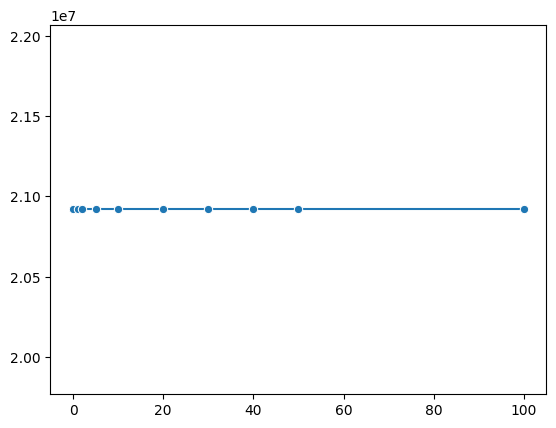

In [10]:
alphas = [0.001, 0.1 ,1 ,2 ,5 ,10 ,20 ,30 ,40 ,50 ,100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=0.5)
    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alphas{a}:" ,mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker="o")
   

In [17]:
from sklearn.linear_model import LassoCV
a = [0.001 , 0.1 , 1 , 2 , 5 , 10 , 20 , 30 , 40 ,  50 , 100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv= 5,
    max_iter=1000,
    random_state=42
    
)
lasso_cv_model.fit(X_train, y_train)
print("best alpha:", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test , y_pred)
print("mse =" , mse)


best alpha: 0.001
mse = 20922599.871035974
